In [20]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# # import  settings
import plot_settings
plot_settings.apply()

In [21]:
# load model
model = pybamm.lithium_ion.DFN()

# create simulation
simulation = pybamm.Simulation(model)

# create geometry
geometry = model.default_geometry

# load parameter values and process model and geometry
param = model.default_parameter_values
param.process_geometry(geometry)
param.process_model(model)


# set mesh
var = pybamm.standard_spatial_vars
var_pts = {var.x_n: 30, var.x_s: 30, var.x_p: 30, var.r_n: 10, var.r_p: 10}
mesh = pybamm.Mesh(geometry, model.default_submesh_types, var_pts)

# discretise model
disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model);

In [22]:
# solve model
t_eval = [0, 3600]
solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
solution = solver.solve(model, t_eval)

In [23]:
# # variables
# for k, v in zip(model.variables.keys(), model.variables.values()):
#     print(f"{k}\t\t{v}")

# model.print_parameter_info()
# print(param)

for var, eq in model.rhs.items():
    print(var, eq)

Discharge capacity [A.h] Column vector of length 1
Throughput capacity [A.h] Column vector of length 1
Negative particle concentration [mol.m-3] Sparse Matrix (300, 300) @ y[2:302] + Sparse Matrix (300, 30) @ (2.0 * 2e-05 * ((maximum(3333.3333333333335 * y[602:632], 1e-08)) ** 0.5) * ((maximum(minimum(Sparse Matrix (30, 300) @ y[2:302], 24983.261744011077), 0.000249832619938437)) ** 0.5) * ((24983.2619938437 - (maximum(minimum(Sparse Matrix (30, 300) @ y[2:302], 24983.261744011077), 0.000249832619938437))) ** 0.5) * sinh(19.460872248113507 * (y[692:722] - (-0.175189434028335 + y[752:782]) - (0.194 + 1.5 * exp(-120.0 * (maximum(minimum(Sparse Matrix (30, 300) @ y[2:302], 0.9999999999), 1e-10))) + 0.0351 * tanh(-3.44578313253012 + 12.048192771084336 * (maximum(minimum(Sparse Matrix (30, 300) @ y[2:302], 0.9999999999), 1e-10))) - (0.0045 * tanh(-7.1344537815126055 + 8.403361344537815 * (maximum(minimum(Sparse Matrix (30, 300) @ y[2:302], 0.9999999999), 1e-10)))) - (0.035 * tanh(-18.466 + 

In [24]:
# plot = pybamm.QuickPlot(solution,
#                     output_variables=[
#                         "Negative particle concentration [mol.m-3]",
#                         "Positive particle concentration",
#                         "Negative electrode potential [V]",
#                         "Positive electrode potential [V]",
#                         "Electrolyte concentration [mol.m-3]",
#                         "Voltage [V]",
#                         "Current [A]",
#                     ])
# plot.dynamic_plot()

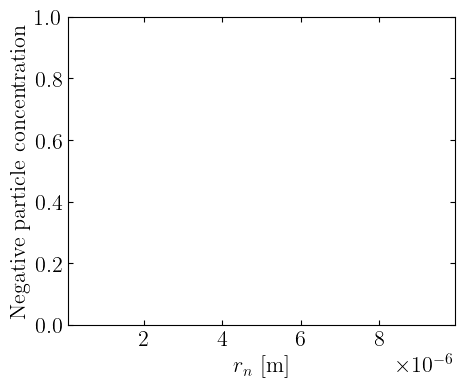

In [25]:
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries[:, 0,1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

def plot_concentrations(t):
    fig, ax1 = plt.subplots(1, 1, figsize=(5, 4))
    
    # Evaluate concentration at specific time and x position (returns values at all r points)
    c_vals = c_s_n(r=r_n, t=t, x=x[0])
    
    # Get the r coordinate values - use entries to get the proper array shape
    r_vals = c_s_n.entries[:, 0, 0]  # Get r values from the data structure
    
    (_plot_c_n,) = ax1.plot(r_n, c_vals)
    ax1.set_ylabel("Negative particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax1.set_ylim(0, 1)

plot_concentrations(t=1800)  # plot at 1800 s

Text(0.5, 1.0, 'Negative particle concentration at t')

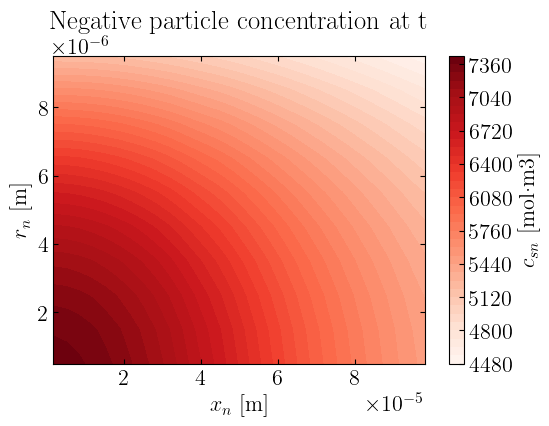

In [43]:
import matplotlib as mpl

# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))

# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
r2d = r_n[..., ti]    # shape (nr, nx)
x2d = x_n[..., ti]    # shape (nx,)

# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[..., ti]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
X, R = np.meshgrid(x2d, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(X, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$x_n$ [m]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at t")

(94,)
(10, 30, 94)
(10, 30, 94)


Text(0.5, 1.0, 'Negative particle concentration at t')

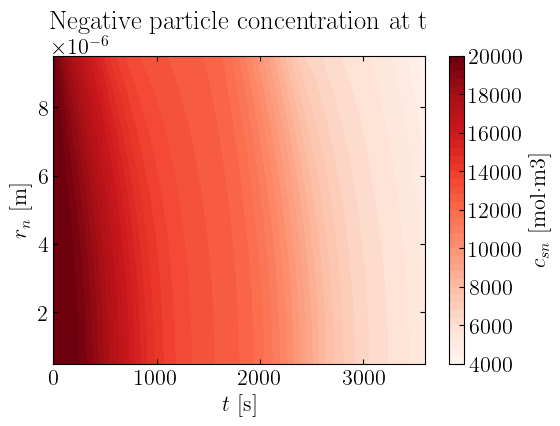

In [51]:
c_s_n = solution["Negative particle concentration [mol.m-3]"].entries
r_n = solution["r_n [m]"].entries 
t_vals = solution["Time [s]"].entries  
print(t_vals.shape)
print(r_n.shape)
print(c_s_n.shape)


t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))



xi =29
r2d = r_n[:,xi,:]    # shape (nr, nx)
c2d = c_s_n[:,xi,:]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
T, R = np.meshgrid(t_vals, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(T, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$t$ [s]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at t")

